# [Deepmath] 6.3. Tensorflow  exemples à deux variables

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

## Importing the modules

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Building the network architecture

In [3]:
# Architecture du réseau
modele = Sequential()
# Couches des neurones
modele.add(Dense(3, input_dim=2, activation='sigmoid'))
modele.add(Dense(1, activation='sigmoid'))
modele.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 3)                 9         
                                                                 
 dense_1 (Dense)             (None, 1)                 4         
                                                                 
Total params: 13
Trainable params: 13
Non-trainable params: 0
_________________________________________________________________


### Couche 0 : Définir les coefficients à la main

In [4]:
coeff = np.array([[1., 3., -5.], [2., -4., -6.]]) # A chaque variable d'entrée correpond une liste
biais = np.array([-1., 0., 1.])
poids = [coeff, biais]
modele.layers[0].set_weights(poids)

### Couche 1 : Définir les coefficients à la main

In [5]:
coeff = np.array([[1.], [1.], [1.]]) # A chaque variable d'entrée correpond une liste
biais = np.array([-3.])
poids = [coeff, biais]
modele.layers[1].set_weights(poids)

In [6]:
# L'entrée est un vecteur de taille égale à input_dim (ici 2)

entry = np.array([[7., -5.]])
sortie = modele.predict(entry)
print("\n Entree : ", entry, "\n Sortie : ", sortie)

1/1 [==============================] - 0s 157ms/step

 Entree :  [[ 7. -5.]] 
 Sortie :  [[0.12303182]]


Il doit être comme une ligne dans une matrice : d'où np.array([[mon vecteur]]). Cette structure des donénes permet de garantir que plusieurs vecteurs de données peuvent être ingérés par le modèle. Il suffit pour ce faire de passer en argument de la méthode .predict une matrice contenant ces vecteurs lignes. L'exemple est dans la cellule suivante.

In [7]:
s = modele.predict(np.array([[7, -5], [2, 3]])) # Une matrice de deux vecteurs lignes V1 et V2
s # Le résultat un vecteur colonne contient les différentes sorties F(V)

1/1 [==============================] - 0s 94ms/step


array([[0.12303182],
       [0.11936697]], dtype=float32)

Pour tracer le graphe, il nous faut plusieurs points. Nous construisons deux vecteurs VX et VY de dimension 30 par la méthode .linspace(). Ensuite, nous construisons une grille pour représenter le plan XY avec la méthode .meshgrid(). Cette méthode nous renvoie deux tableaux X et Y permettant de construire des couples (produits cartésiens) qui constituent notre grille.

Pour pouvoir contruire une matrice de 2 X 30 (c'est à dire une matrice de 30 vecteurs lignes de taille 2), nous utilisons la méthode np.c_[X.ravel(), Y.ravel()].

Il ne suffit plus qu'à passer cette matrice en argument de la méthiode .predict() pour obtenir les résultats.

In [8]:
VX = np.linspace(-5, 5, 30)
VY = np.linspace(-5, 5, 30)
X, Y = np.meshgrid(VX, VY)

In [9]:
entreePrime = np.c_[X.ravel(), Y.ravel()]
sortiePrime = modele.predict(entreePrime)

29/29 [==============================] - 0s 2ms/step


In [10]:
Z = sortiePrime.reshape(X.shape) # Ajuster Z à la taille des vecteurs X et Y

### Tracer le graphe de la fonction F(x, y)

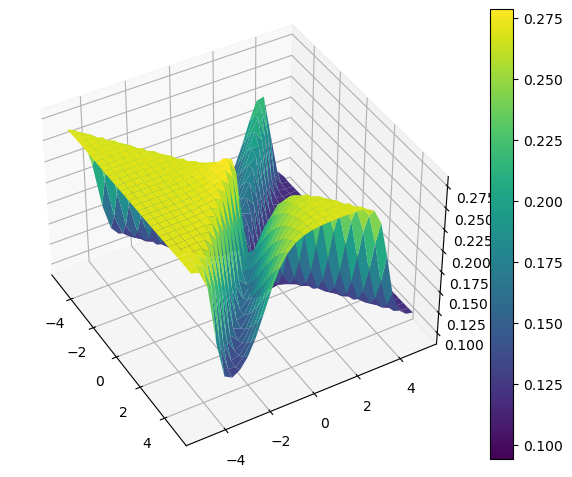

In [17]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.view_init(40, -30)
graph = ax.plot_surface(X, Y, Z, cmap='viridis')
plt.colorbar(graph)
plt.tight_layout()
plt.show()